In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
from skbio import DistanceMatrix
from skbio.tree import nj
from skbio.tree import upgma
from skbio.tree import bme
from skbio import TreeNode

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec

from Bio import Phylo
import numpy as np

import glob,os,copy,requests
from io import StringIO
import requests

import baltic as bt


Pruning the tree so it only has the species of interest.

In [3]:
primate_tree = TreeNode.read("../data/Craig_Kumar_Hedges_final_timetree.nwk")
primate_tree

<TreeNode, name: unnamed, internal node count: 453, tips count: 455>

In [4]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [5]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [6]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mating_vas

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN


In [7]:
mean_pi_df = all_pi_df.loc[all_pi_df.callable_frac >= 0.5].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "aut"]
chrx_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi"]].std() / all_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
CV_x_df = (chrx_pi_df_aut.groupby(["species"])[["pi"]].std() / chrx_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()
mean_pi_df["CV_x"] = mean_pi_df.species.map(dict(zip(CV_x_df.species, CV_x_df.pi)))
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["binomial_name"] = [x[:-4] for x in mean_pi_df.species]
mean_pi_df["strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.consensus)))
mean_pi_df["strategy"] = ["conflicting" if pd.isna(x) else x for x in mean_pi_df["strategy"]]

In [8]:
mean_pi_df

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,Polygynandrous
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,Polygynous
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,Polygynous
3,Allochrocebus_solatus_ssp,302.877750,NaN,0.712146,NaN,0.003029,NaN,NaN,NaN,Allochrocebus_solatus,Polygynous
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,Polygynous
...,...,...,...,...,...,...,...,...,...,...,...
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,conflicting
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,conflicting
248,Varecia_rubra_ssp,151.034928,NaN,0.762300,NaN,0.001510,NaN,NaN,NaN,Varecia_rubra,conflicting
249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,conflicting


In [9]:
species_with_x = mean_pi_df.loc[~mean_pi_df["X/A ratio"].isna()].reset_index()

In [10]:
species_list = ["{} {}".format(x.split("_")[0], x.split("_")[1]) for x in species_with_x.species.unique()]
species_with_x["Binomial name"] = species_list
species_list

['Allenopithecus nigroviridis',
 'Allochrocebus lhoesti',
 'Allochrocebus preussi',
 'Alouatta belzebul',
 'Alouatta discolor',
 'Alouatta juara',
 'Alouatta macconnelli',
 'Alouatta palliata',
 'Alouatta seniculus',
 'Aotus azarai',
 'Aotus griseimembra',
 'Aotus nancymaae',
 'Aotus trivirgatus',
 'Aotus vociferans',
 'Arctocebus calabarensis',
 'Ateles belzebuth',
 'Ateles chamek',
 'Ateles geoffroyi',
 'Ateles marginatus',
 'Ateles paniscus',
 'Avahi peyrierasi',
 'Brachyteles hypoxanthus',
 'Cacajao ayresi',
 'Cacajao calvus',
 'Cacajao hosomi',
 'Cacajao melanocephalus',
 'Callimico goeldii',
 'Callithrix jacchus',
 'Cebuella niveiventris',
 'Cebuella pygmaea',
 'Cebus albifrons',
 'Cebus imitator',
 'Cebus olivaceus',
 'Cebus unicolor',
 'Cercocebus atys',
 'Cercocebus chrysogaster',
 'Cercopithecus ascanius',
 'Cercopithecus campbelli',
 'Cercopithecus cephus',
 'Cercopithecus denti',
 'Cercopithecus hamlyni',
 'Cercopithecus mitis',
 'Cercopithecus mona',
 'Cercopithecus neglec

In [11]:
trimmed_list = []
for node in primate_tree.tips():
    if node.name in species_list:
        trimmed_list.append(node.name)

In [12]:
trimmed_list

['Pan troglodytes',
 'Pan paniscus',
 'Gorilla gorilla',
 'Gorilla beringei',
 'Pongo pygmaeus',
 'Pongo abelii',
 'Hylobates agilis',
 'Hylobates lar',
 'Hylobates pileatus',
 'Symphalangus syndactylus',
 'Hoolock leuconedys',
 'Hoolock hoolock',
 'Nomascus gabriellae',
 'Nomascus siki',
 'Cercocebus atys',
 'Cercocebus chrysogaster',
 'Mandrillus sphinx',
 'Mandrillus leucophaeus',
 'Papio ursinus',
 'Papio cynocephalus',
 'Papio kindae',
 'Papio hamadryas',
 'Papio anubis',
 'Papio papio',
 'Lophocebus aterrimus',
 'Theropithecus gelada',
 'Macaca radiata',
 'Macaca leucogenys',
 'Macaca thibetana',
 'Macaca assamensis',
 'Macaca arctoides',
 'Macaca fascicularis',
 'Macaca mulatta',
 'Macaca cyclopis',
 'Macaca fuscata',
 'Macaca silenus',
 'Macaca leonina',
 'Macaca nemestrina',
 'Macaca brunnescens',
 'Macaca maura',
 'Macaca tonkeana',
 'Macaca nigra',
 'Macaca hecki',
 'Macaca sylvanus',
 'Cercopithecus ascanius',
 'Cercopithecus cephus',
 'Cercopithecus nictitans',
 'Cercopith

In [13]:
primate_tree.shear(trimmed_list).write("../data/trimmed_primate_tree.nwk")

'../data/trimmed_primate_tree.nwk'

In [14]:
species_with_x

chr_type,index,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy,Binomial name
0,0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,Polygynandrous,Allenopithecus nigroviridis
1,1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,Polygynous,Allochrocebus lhoesti
2,2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,Polygynous,Allochrocebus preussi
3,4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,Polygynous,Alouatta belzebul
4,6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,Polygynous,Alouatta discolor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,Polygynous,Trachypithecus pileatus
189,246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,conflicting,Trachypithecus poliocephalus
190,247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,conflicting,Trachypithecus vetulus
191,249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,conflicting,Varecia variegata


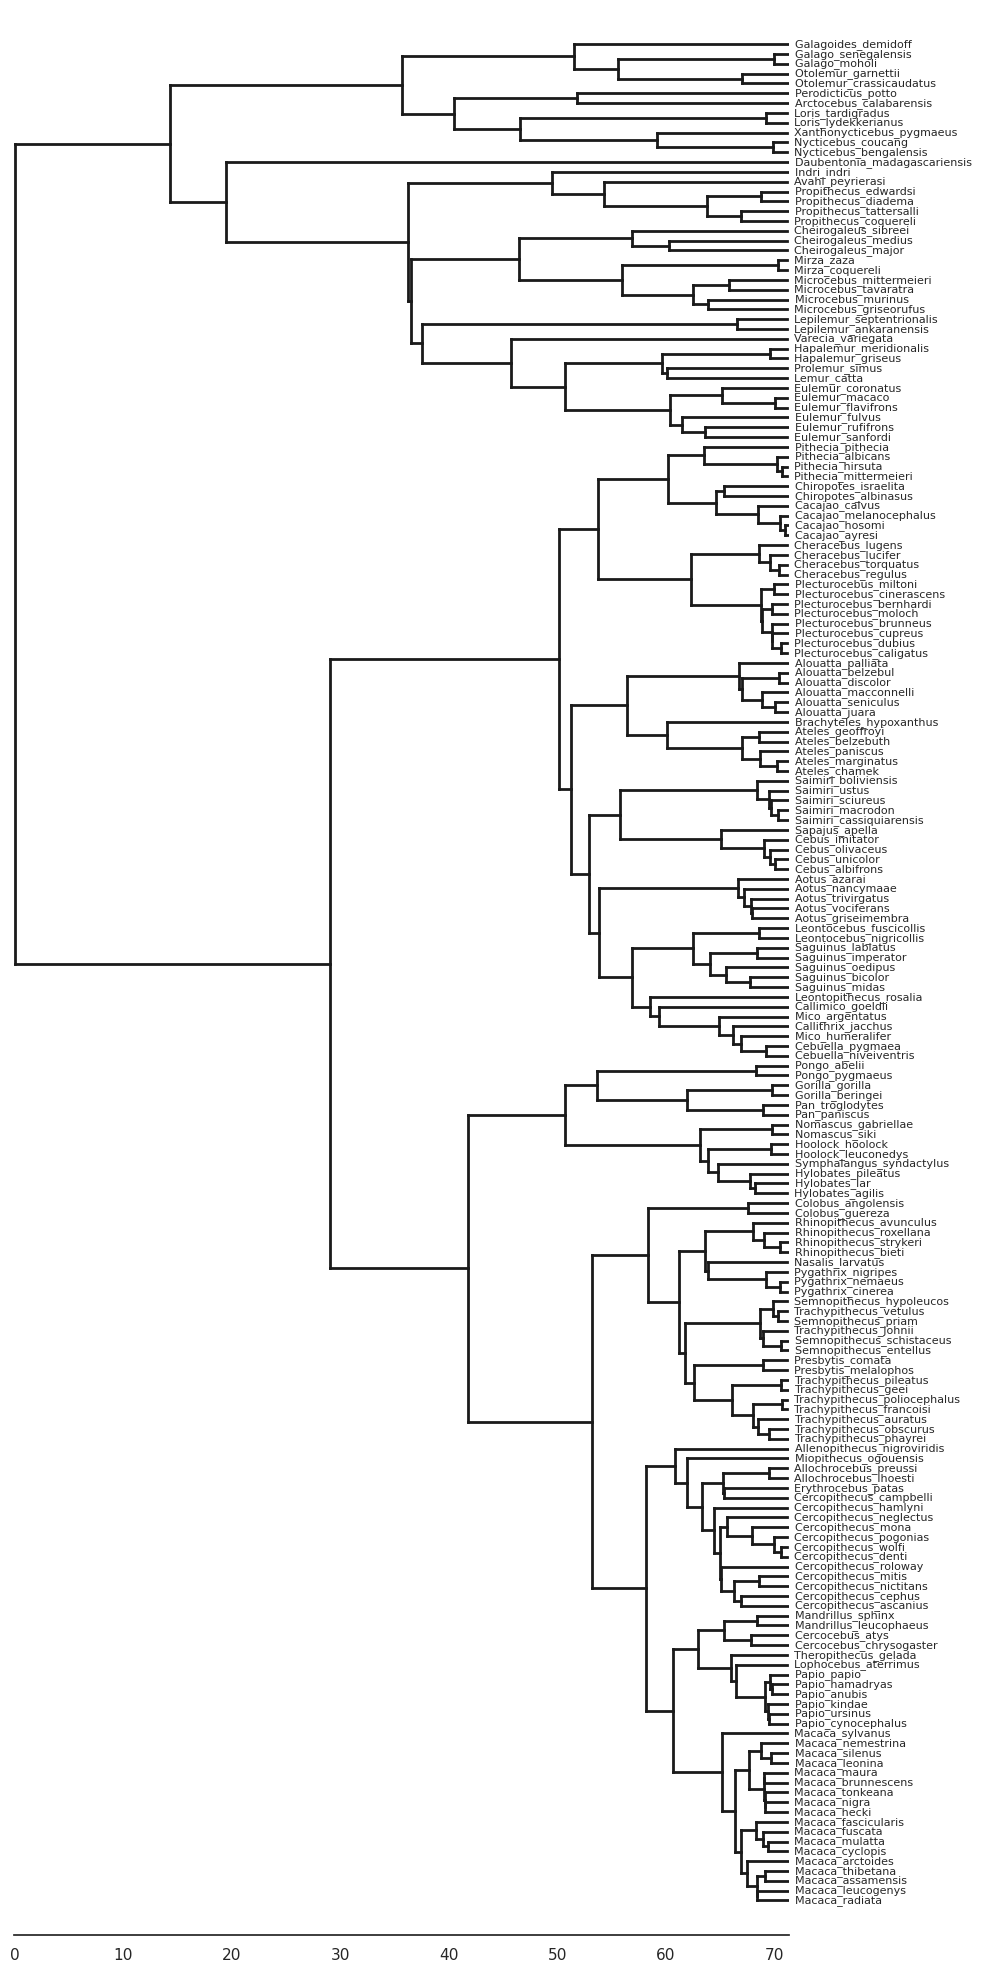

In [15]:
# Variation based on a gallery example
tree = bt.loadNewick("../data/trimmed_primate_tree.nwk")
#tree.sortBranches()
tree.drawTree()
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 25))
ax.set_ylim(-3,tree.ySpan+3)
ax.set_xlim(-0.1,tree.treeHeight+0.1)
ax.set_yticks([])
ax.set_yticklabels([])

target_func=lambda k: k.is_leaf() ## which branches will be annotated
text_func=lambda k: "  "+k.name ## what text is plotted. Added two spaces, x_attr somehow fails
kwargs={'va':'center','ha':'left','size': 8} ## kwargs for text

tree.addText(ax,target=target_func,text=text_func,**kwargs) ## text will use a different x attribute 


# Plot the tree
tree.plotTree(ax)
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
plt.show()

In [16]:
species_with_x_and_tree = species_with_x.loc[species_with_x["Binomial name"].isin(trimmed_list)]
species_with_x_and_tree['Binomial name'] = pd.Categorical(species_with_x_and_tree['Binomial name'], categories=trimmed_list, ordered=True)

/tmp/34748698/ipykernel_2669521/3840624021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree['Binomial name'] = pd.Categorical(species_with_x_and_tree['Binomial name'], categories=trimmed_list, ordered=True)


In [17]:
species_with_x_and_tree.sort_values(["Binomial name"])

chr_type,index,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy,Binomial name
129,161,Pan_troglodytes_ssp,175.943834,120.666763,0.478890,0.435661,0.001759,0.001207,0.685825,0.685825,Pan_troglodytes,Polygynandrous,Pan troglodytes
128,160,Pan_paniscus_ssp,84.169136,55.852667,0.613750,0.565961,0.000842,0.000559,0.663577,0.663577,Pan_paniscus,Polygynandrous,Pan paniscus
73,90,Gorilla_gorilla_ssp,188.938321,104.608068,0.625608,0.821158,0.001889,0.001046,0.553663,0.553663,Gorilla_gorilla,Polygynous,Gorilla gorilla
72,89,Gorilla_beringei_ssp,112.538515,50.857913,0.785494,1.125244,0.001125,0.000509,0.451916,0.451916,Gorilla_beringei,Polygynous,Gorilla beringei
150,190,Pongo_pygmaeus_ssp,190.461962,68.777545,0.587609,0.888452,0.001905,0.000688,0.361109,0.361109,Pongo_pygmaeus,Polygynous,Pongo pygmaeus
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,87,Galago_senegalensis_ssp,330.173987,193.620951,0.382056,0.566934,0.003302,0.001936,0.586421,0.586421,Galago_senegalensis,Polygynous,Galago senegalensis
69,86,Galago_moholi_ssp,163.429494,63.883573,0.655587,1.112770,0.001634,0.000639,0.390894,0.390894,Galago_moholi,Polygynous,Galago moholi
127,159,Otolemur_garnettii_ssp,224.297772,119.587633,0.582165,0.964966,0.002243,0.001196,0.533165,0.533165,Otolemur_garnettii,conflicting,Otolemur garnettii
126,158,Otolemur_crassicaudatus_ssp,160.722120,114.098904,0.430408,0.523526,0.001607,0.001141,0.709914,0.709914,Otolemur_crassicaudatus,Polygynous,Otolemur crassicaudatus


Generating the tree with colored tips based on X/A ratio.

In [18]:
tree = bt.loadNewick("../data/trimmed_primate_tree.nwk")

for leaf in tree.getExternal():
    name = leaf.name  # or leaf.numName if using Nexus numeric names
    leaf.traits["X/A Ratio"] = species_with_x_and_tree.loc[species_with_x_and_tree.binomial_name == name, "X/A ratio"].values[0]

In [19]:
for leaf in tree.getExternal():
    print(leaf.traits["X/A Ratio"])

0.6636083312737285
0.6397956104743863
0.546089916517369
0.559279056810564
0.5306400116827865
0.40099990820291226
0.36612725941288493
0.624991179192738
0.5028323804584152
0.4988842350899283
0.4067226347996822
0.5683446146415175
0.5542051220643625
0.6951664249758474
0.32510648899002276
0.3175650849617625
0.4831762858559503
0.40144978950093707
0.34279251101989067
0.44525002453633805
0.429233597983966
0.4215893108150477
0.2690334812376367
0.5475338951322605
0.500326105218957
0.36835415885378936
0.5964728038689898
0.5415995344441286
0.48220042153397735
0.5548685247406122
0.5093381891125084
0.5228422217065111
0.6209694082652253
0.8384671898448094
0.8228677197977544
0.8330979030426883
0.5864209726769963
0.39089377904848277
0.5331646037569433
0.7099141294536908
0.5113471314368163
0.5536625254830834
0.45191561983468925
0.6858254686742803
0.663576574810929
0.6159535854707294
0.3611090856003295
0.5449513763503329
0.6862819799911493
0.6337972276866531
0.6370405654076382
0.6667392172854498
0.513860

In [20]:
# Setting up the palette
palette = sns.color_palette("coolwarm_r", as_cmap=True)
# Alternative palettes
#palette = sns.color_palette("flare", as_cmap=True)
mean_XA = species_with_x_and_tree["X/A ratio"].mean()

Text(0.5, 1.0, 'X/A Ratio')

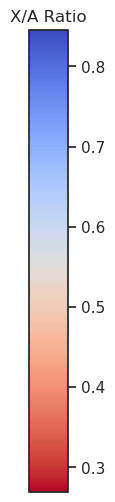

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

vmin = species_with_x_and_tree["X/A ratio"].min()
vmax = species_with_x_and_tree["X/A ratio"].max()

fig, ax = plt.subplots(figsize=(0.5, 6))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=palette, norm=norm),
    cax=ax,
    orientation="vertical",
    ticklocation="right"
)
#cbar.set_label("X/A Ratio", rotation=0, labelpad=10)
ax.set_title("X/A Ratio")


Text(0.5, 1.0, 'X/A Ratio')

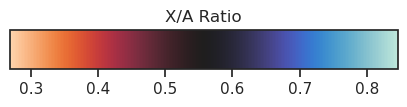

In [22]:
palette = sns.color_palette("icefire_r", as_cmap=True)
vmin = species_with_x_and_tree["X/A ratio"].min()
vmax = species_with_x_and_tree["X/A ratio"].max()

fig, ax = plt.subplots(figsize=(5, 0.5))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=palette, norm=norm),
    cax=ax,
    orientation="horizontal"
)
#cbar.set_label("X/A Ratio", rotation=0, labelpad=10)
ax.set_title("X/A Ratio")


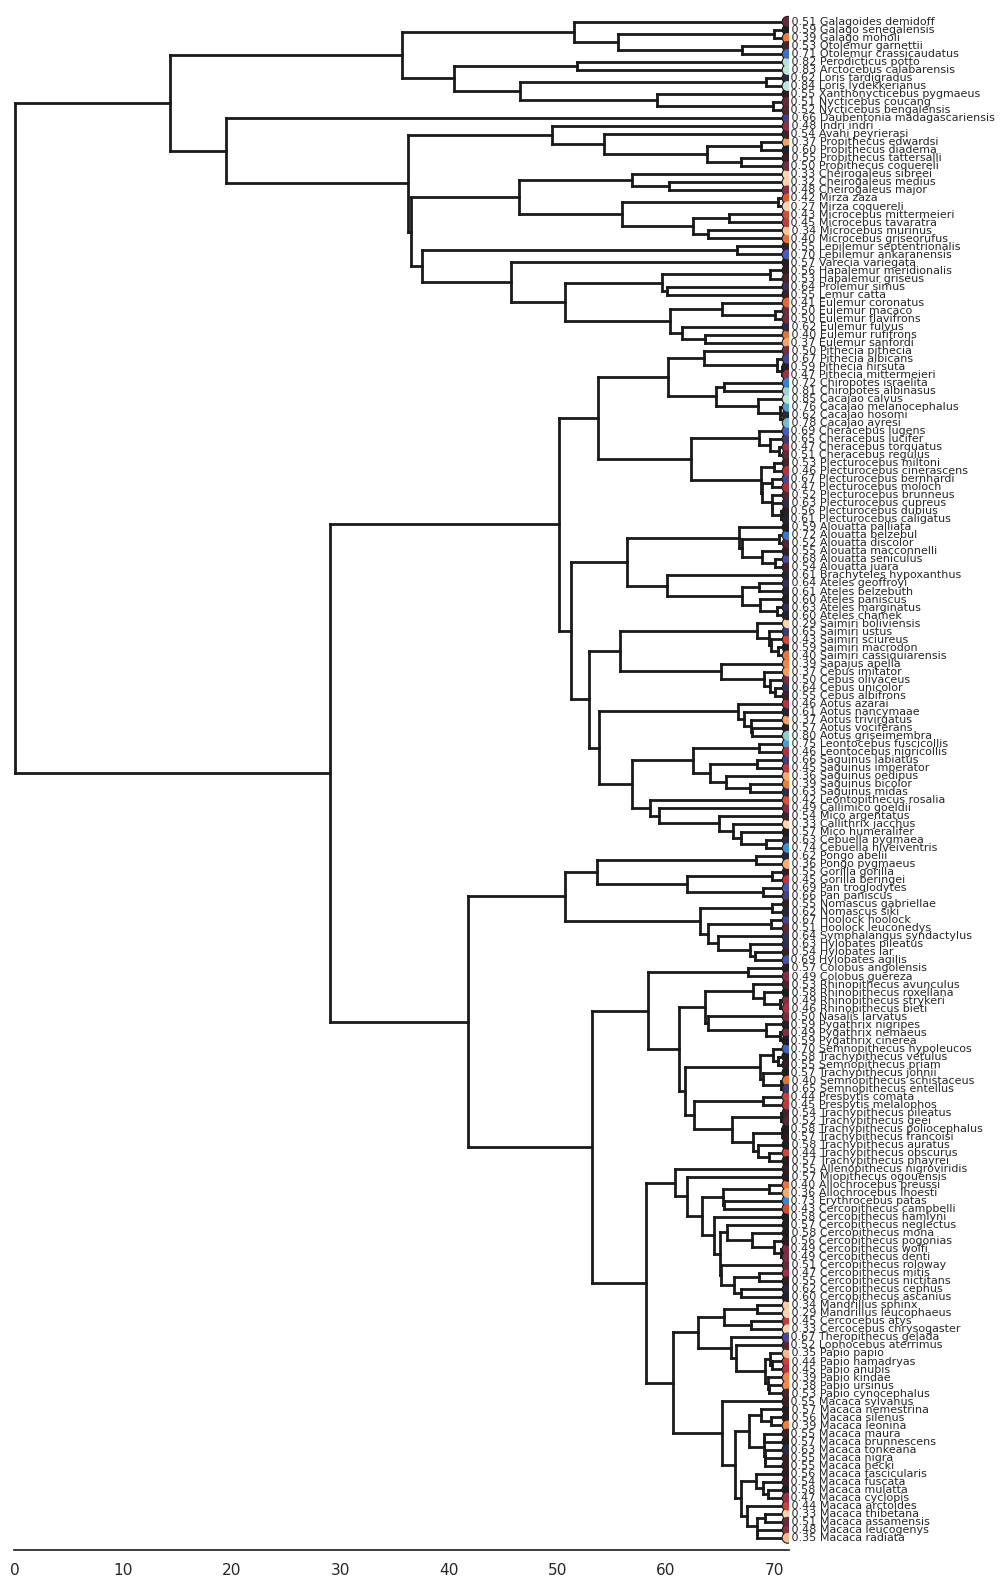

In [49]:
tree.drawTree()
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 20))
ax.set_ylim(-1,tree.ySpan+1)
ax.set_xlim(-0.1,tree.treeHeight+0.1)
ax.set_yticks([])
ax.set_yticklabels([])


target_func=lambda k: k.is_leaf() ## which branches will be annotated
text_func=lambda k: " {:.2f} {} {}".format(k.traits['X/A Ratio'], k.name.split("_")[0], k.name.split("_")[1]) ## what text is plotted. Added two spaces, x_attr somehow fails
c_func=lambda k: palette(k.traits['X/A Ratio']*2-0.66)

kwargs={'va':'center','ha':'left','size': 8} ## kwargs for text

tree.addText(ax,target=target_func,text=text_func,**kwargs) ## text will use a different x attribute 
tree.plotPoints(ax,size=50,colour=c_func,zorder=100,outline_size=50*1.5)


# Plot the tree
tree.plotTree(ax)
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
plt.show()

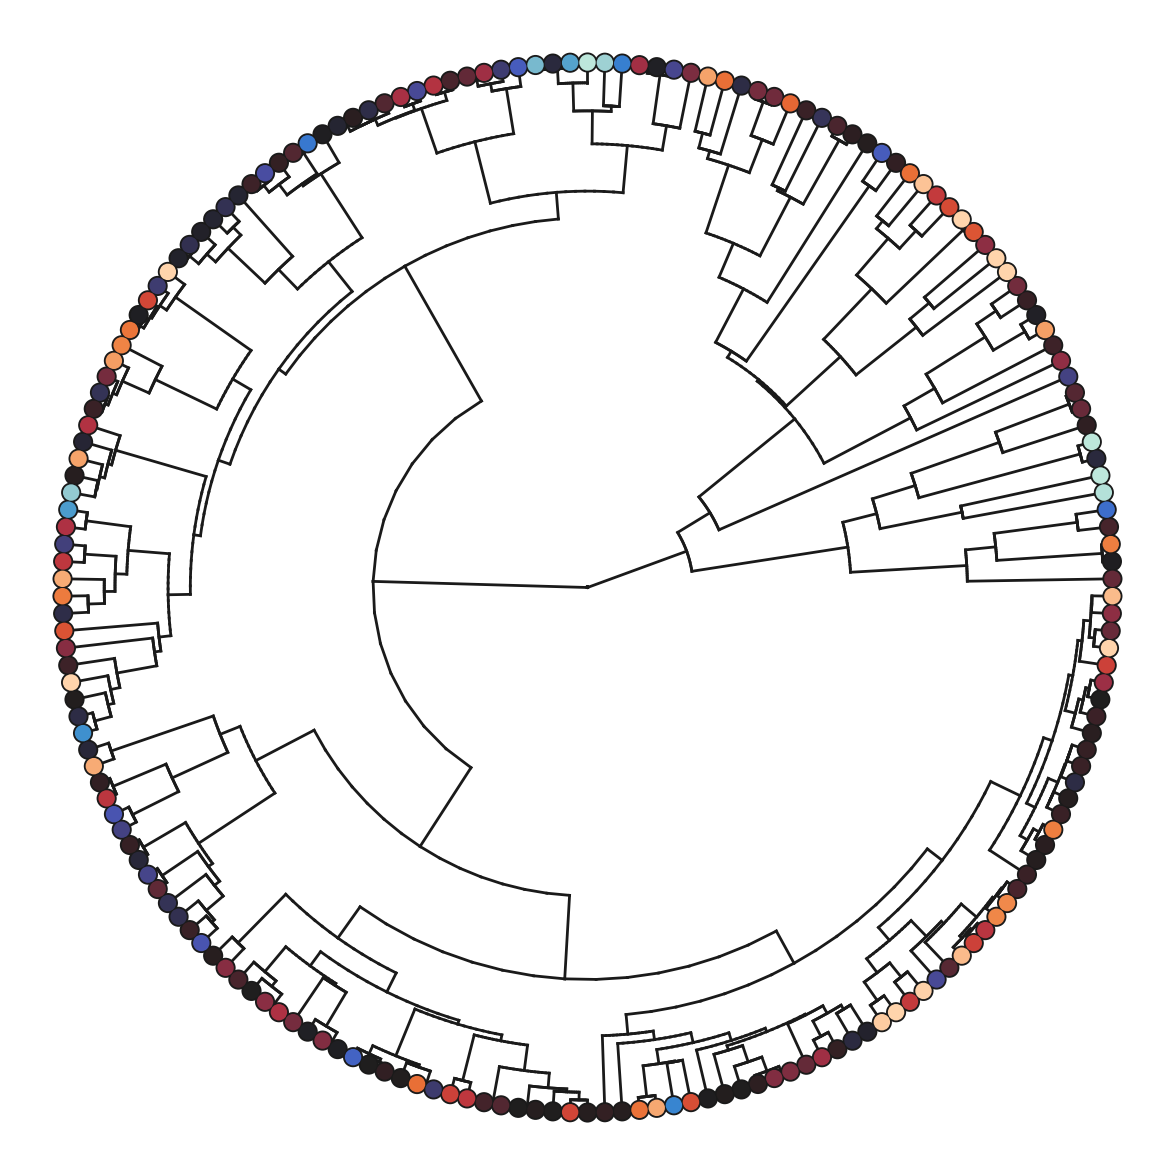

In [53]:
fig = plt.subplots(figsize=(15,15),facecolor='w')

ax = plt.subplot()

c_func=lambda k: palette(k.traits['X/A Ratio']*2-0.66)

tree.plotCircularTree(ax,circStart=0.25,circFrac=1,inwardSpace=0.001*tree.treeHeight) 
tree.plotCircularPoints(ax,circStart=0.25,circFrac=1,colour=c_func,inwardSpace=0.001*tree.treeHeight,
                        size=140,outline_size=140*1.5)

ax.plot()

[ax.spines[loc].set_visible(False) for loc in ax.spines]
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_aspect(1)
plt.show()

Phylogenetic regression.
I use r-ape to generate the covariance matrix based on this tree.

In [25]:
primate_tree_trim = TreeNode.read("../data/trimmed_primate_tree.nwk")
primate_tree_trim

<TreeNode, name: unnamed, internal node count: 188, tips count: 190>

In [26]:
covariance_matrix = pd.read_csv("../data/trimmed_cov.csv", header=None)
covariance_matrix

,0,1,2,3,4,5,6,7,8,9,...,180,181,182,183,184,185,186,187,188,189
0,71.23,19.42,19.42,19.42,19.42,19.42,19.42,19.42,19.42,19.42,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,19.42,71.22,60.09,59.67,59.67,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,19.42,60.09,71.22,59.67,59.67,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,19.42,59.67,59.67,71.22,69.63,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,19.42,59.67,59.67,69.63,71.22,50.70,50.70,50.70,50.70,50.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,70.97,71.24,70.51,68.47,64.66,64.66
186,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,70.51,70.51,71.24,68.47,64.66,64.66
187,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,68.47,68.47,68.47,71.23,64.66,64.66
188,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,60.19,60.19,60.19,60.19,64.66,64.66,64.66,64.66,71.24,65.39


In [27]:
species_with_x_and_tree

chr_type,index,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy,Binomial name
0,0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,Polygynandrous,Allenopithecus nigroviridis
1,1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,Polygynous,Allochrocebus lhoesti
2,2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,Polygynous,Allochrocebus preussi
3,4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,Polygynous,Alouatta belzebul
4,6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,Polygynous,Alouatta discolor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,Polygynous,Trachypithecus pileatus
189,246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,conflicting,Trachypithecus poliocephalus
190,247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,conflicting,Trachypithecus vetulus
191,249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,conflicting,Varecia variegata


In [28]:
import statsmodels.formula.api as smf

# First, the simplest regression case
glm_results = smf.gls(formula = "chrX ~ aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                   chrX   R-squared:                       0.864
Model:                            GLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     1193.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.47e-83
Time:                        14:46:15   Log-Likelihood:                -968.07
No. Observations:                 190   AIC:                             1940.
Df Residuals:                     188   BIC:                             1947.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8416     60.772     -0.014      0.989    -120.724     119.041
aut            0.5526      0.016     34.537      0.000       0.521       0.584
==============================================================================
Omnibus:                       88.174   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1103.930
Skew:                          -1.363   Prob(JB):                    1.93e-240
Kurtosis:                      14.490   Cond. No.                     3.80e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [55]:
# First, the simplest regression case
glm_results = smf.gls(formula = "chrX ~ aut+aut:strategy", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                   chrX   R-squared:                       0.876
Model:                            GLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     260.2
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.06e-81
Time:                        15:15:29   Log-Likelihood:                -959.12
No. Observations:                 190   AIC:                             1930.
Df Residuals:                     184   BIC:                             1950.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -4.2862     58.643     -0.073      0.942    -119.986     111.413
aut                                0.5466      0.028     19.783      0.000       0.492       0.601
aut:strategy[T.Polyandrous]       -0.0330      0.040     -0.817      0.415      -0.113       0.047
aut:strategy[T.Polygynandrous]     0.0615      0.033      1.841      0.067      -0.004       0.127
aut:strategy[T.Polygynous]        -0.0296      0.030     -0.996      0.320      -0.088       0.029
aut:strategy[T.conflicting]        0.0276      0.028      1.003      0.317      -0.027       0.082
==============================================================================
Omnibus:                       41.569   Durbin-Watson:                   1.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              295.857
Skew:                          -0.532   Prob(JB):                     5.70e-65
Kurtosis:                       9.020   Cond. No.                     4.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
species_with_x_and_tree.groupby(["strategy"])[["X_a_ratio"]].mean()

chr_type,X_a_ratio
strategy,
Monogamous,0.569853
Polyandrous,0.500326
Polygynandrous,0.518265
Polygynous,0.527080
conflicting,0.546628


So while the monogamous species generally have a higher X/A ratio, the slope of Polygynandrous species is steeper.
However, the strategies generally overlap in their confidence intervals.

In [59]:
# X/A ratio does not strongly depend on just autosomal diversity.
# But there is a small signal that X/A ratio increases with higher autosomal diversity
glm_results = smf.gls(formula = "X_a_ratio ~ aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.061
Model:                            GLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     12.27
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           0.000574
Time:                        15:15:44   Log-Likelihood:                 83.300
No. Observations:                 190   AIC:                            -162.6
Df Residuals:                     188   BIC:                            -156.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5038      0.240      2.098      0.037       0.030       0.978
aut            0.0002   6.32e-05      3.504      0.001    9.68e-05       0.000
==============================================================================
Omnibus:                       46.788   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              304.671
Skew:                          -0.694   Prob(JB):                     6.94e-67
Kurtosis:                       9.046   Cond. No.                     3.80e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='chrX', ylabel='X_a_ratio'>

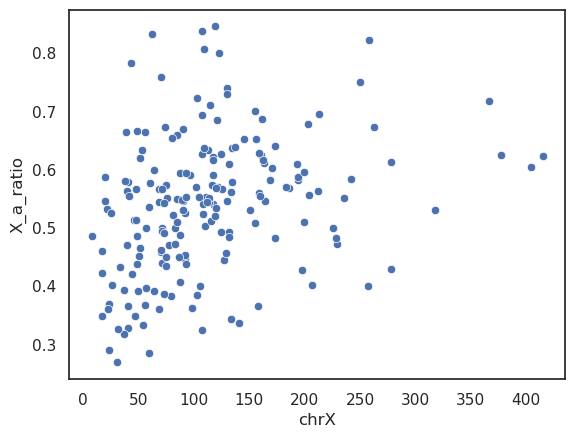

In [32]:
sns.scatterplot(species_with_x_and_tree, x="chrX", y="X_a_ratio")

In [62]:
glm_results = smf.gls(formula = "CV_x ~ CV_aut", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                   CV_x   R-squared:                       0.754
Model:                            GLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     575.5
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           4.08e-59
Time:                        15:16:00   Log-Likelihood:                -26.046
No. Observations:                 190   AIC:                             56.09
Df Residuals:                     188   BIC:                             62.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0317      0.427      0.074      0.941      -0.811       0.875
CV_aut         1.1911      0.050     23.990      0.000       1.093       1.289
==============================================================================
Omnibus:                       74.594   Durbin-Watson:                   2.268
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              670.276
Skew:                          -1.186   Prob(JB):                    2.83e-146
Kurtosis:                      11.890   Cond. No.                         8.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
species_with_x_and_tree

chr_type,index,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,strategy,Binomial name
0,0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,Polygynandrous,Allenopithecus nigroviridis
1,1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,Polygynous,Allochrocebus lhoesti
2,2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,Polygynous,Allochrocebus preussi
3,4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,Polygynous,Alouatta belzebul
4,6,Alouatta_discolor_ssp,206.429698,108.086733,0.604936,0.623321,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,Polygynous,Alouatta discolor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,245,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.762625,0.921115,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,Polygynous,Trachypithecus pileatus
189,246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,conflicting,Trachypithecus poliocephalus
190,247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,conflicting,Trachypithecus vetulus
191,249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,conflicting,Varecia variegata


In [35]:
# If you are using CV of chromosome X, CV of autosomes have no information.
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut+aut*CV_x", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.300
Model:                            GLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     15.77
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           6.47e-13
Time:                        14:46:15   Log-Likelihood:                 111.18
No. Observations:                 190   AIC:                            -210.4
Df Residuals:                     184   BIC:                            -190.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5580      0.212      2.630      0.009       0.139       0.976
aut            0.0006      0.000      3.693      0.000       0.000       0.001
CV_aut         0.0446      0.059      0.755      0.451      -0.072       0.161
aut:CV_aut  2.195e-07      0.000      0.001      1.000      -0.001       0.001
CV_x          -0.0587      0.050     -1.168      0.244      -0.158       0.040
aut:CV_x      -0.0009      0.000     -3.649      0.000      -0.001      -0.000
==============================================================================
Omnibus:                      100.691   Durbin-Watson:                   1.774
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1321.541
Skew:                          -1.628   Prob(JB):                    1.07e-287
Kurtosis:                      15.503   Cond. No.                     4.61e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.61e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [36]:
glm_results = smf.gls(formula = "X_a_ratio ~ strategy+aut*CV_x", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.376
Model:                            GLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     15.63
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           5.56e-16
Time:                        14:46:15   Log-Likelihood:                 122.02
No. Observations:                 190   AIC:                            -228.0
Df Residuals:                     182   BIC:                            -202.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.5642      0.203      2.775      0.006       0.163       0.965
strategy[T.Polyandrous]       -0.0229      0.056     -0.411      0.682      -0.133       0.087
strategy[T.Polygynandrous]    -0.0147      0.032     -0.453      0.651      -0.079       0.049
strategy[T.Polygynous]        -0.0333      0.029     -1.135      0.258      -0.091       0.025
strategy[T.conflicting]        0.0422      0.026      1.632      0.104      -0.009       0.093
aut                            0.0007      0.000      4.519      0.000       0.000       0.001
CV_x                          -0.0204      0.030     -0.688      0.493      -0.079       0.038
aut:CV_x                      -0.0010      0.000     -5.424      0.000      -0.001      -0.001
==============================================================================
Omnibus:                       34.160   Durbin-Watson:                   1.751
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              235.782
Skew:                          -0.336   Prob(JB):                     6.32e-52
Kurtosis:                       8.416   Cond. No.                     4.43e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.43e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group))

{'Allenopithecus_nigroviridis_ssp': 'OWM',
 'Aotus_azarai_ssp': 'PLA',
 'Aotus_griseimembra_ssp': 'PLA',
 'Aotus_nancymaae_ssp': 'PLA',
 'Aotus_trivirgatus_ssp': 'PLA',
 'Aotus_vociferans_ssp': 'PLA',
 'Alouatta_belzebul_ssp': 'PLA',
 'Alouatta_caraya_ssp': 'PLA',
 'Alouatta_discolor_ssp': 'PLA',
 'Alouatta_juara_ssp': 'PLA',
 'Alouatta_macconnelli_ssp': 'PLA',
 'Alouatta_palliata_ssp': 'PLA',
 'Alouatta_seniculus_ssp': 'PLA',
 'Ateles_belzebuth_ssp': 'PLA',
 'Ateles_chamek_ssp': 'PLA',
 'Ateles_geoffroyi_ssp': 'PLA',
 'Ateles_marginatus_ssp': 'PLA',
 'Ateles_paniscus_ssp': 'PLA',
 'Brachyteles_hypoxanthus_ssp': 'PLA',
 'Lagothrix_lagotricha_ssp': 'PLA',
 'Callimico_goeldii_ssp': 'PLA',
 'Callithrix_geoffroyi_ssp': 'PLA',
 'Callithrix_jacchus_ssp': 'PLA',
 'Callithrix_kuhlii_ssp': 'PLA',
 'Cebuella_niveiventris_ssp': 'PLA',
 'Cebuella_pygmaea_ssp': 'PLA',
 'Mico_argentatus_ssp': 'PLA',
 'Mico_humeralifer_ssp': 'PLA',
 'Mico_humilis_ssp': 'PLA',
 'Carlito_syrichta_ssp': 'TAR',
 'Cephalo

In [38]:
species_with_x_and_tree["group"] = species_with_x_and_tree.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))

/tmp/34748698/ipykernel_2669521/2820848254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["group"] = species_with_x_and_tree.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))


In [39]:
glm_results = smf.gls(formula = "X_a_ratio ~ aut:group+aut*CV_x", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.323
Model:                            GLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     14.56
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           1.45e-13
Time:                        14:46:16   Log-Likelihood:                 114.38
No. Observations:                 190   AIC:                            -214.8
Df Residuals:                     183   BIC:                            -192.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.6147      0.211      2.915      0.004       0.199       1.031
aut                  0.0003      0.001      0.589      0.557      -0.001       0.001
aut:group[T.OWM]  5.685e-05      0.001      0.104      0.918      -0.001       0.001
aut:group[T.PLA]     0.0004      0.001      0.756      0.451      -0.001       0.002
aut:group[T.STR]     0.0004      0.001      0.706      0.481      -0.001       0.001
CV_x                -0.0400      0.031     -1.287      0.200      -0.101       0.021
aut:CV_x            -0.0010      0.000     -4.943      0.000      -0.001      -0.001
==============================================================================
Omnibus:                       97.505   Durbin-Watson:                   1.746
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1579.613
Skew:                          -1.476   Prob(JB):                         0.00
Kurtosis:                      16.814   Cond. No.                     5.14e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

I also performed this regression in caper with a kappa of 2. R-square there was 0.31.
However, it's not possible to combine quantitative and qualitative variables in caper.
Below I check whether the distribution of 1-2 and 3+ populations differ.

In [40]:
s_count = []
for s in species_with_x_and_tree.species:
    s_count.append(len(metadata_20x_filt.loc[metadata_20x_filt.species_genotyping == s]))
species_with_x_and_tree["sample_count"] = s_count

/tmp/34748698/ipykernel_2669521/3348411378.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_with_x_and_tree["sample_count"] = s_count


In [41]:
species_with_x_and_tree.sort_values(["Binomial name"]).sample_count

129    94
128    15
73     29
72     20
150    16
       ..
70      2
69      2
127     3
126     2
71      1
Name: sample_count, Length: 190, dtype: int64

<Axes: xlabel='sample_count', ylabel='X_a_ratio'>

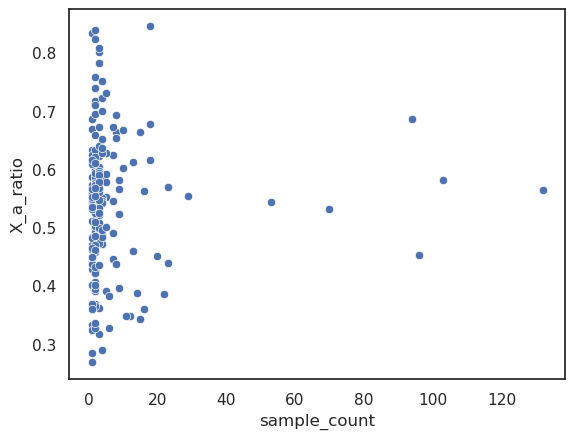

In [42]:
sns.scatterplot(species_with_x_and_tree, x="sample_count", y="X_a_ratio")

In [43]:
species_with_x_and_tree.sample_count.median()

2.5

<Axes: xlabel='X_a_ratio', ylabel='Count'>

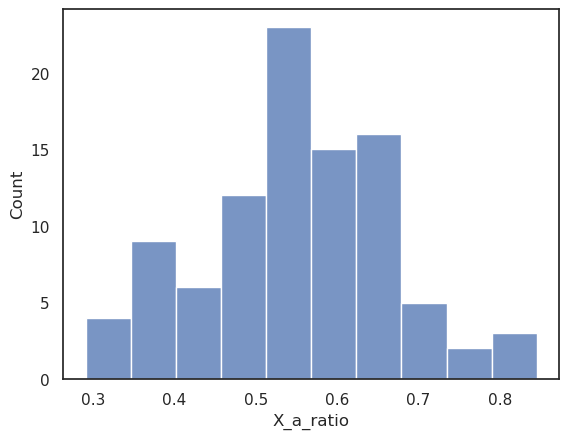

In [44]:
sns.histplot(species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3], x="X_a_ratio")

<Axes: xlabel='X_a_ratio', ylabel='Count'>

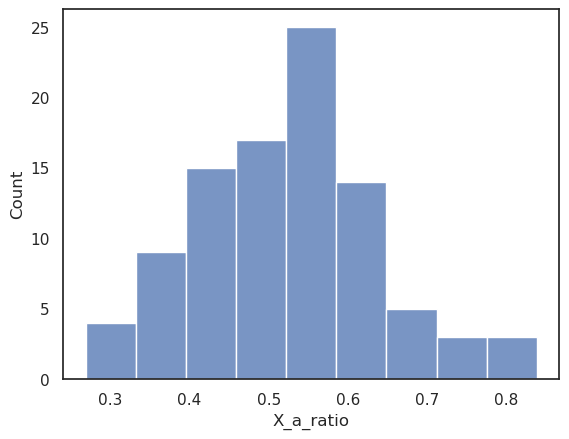

In [45]:
sns.histplot(species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3], x="X_a_ratio")

In [46]:
species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3].X_a_ratio.mean(), species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3].X_a_ratio.mean()

(0.5536085865449902, 0.5234882852999322)

In [47]:
species_with_x_and_tree.loc[species_with_x_and_tree.sample_count >= 3].X_a_ratio.var(), species_with_x_and_tree.loc[species_with_x_and_tree.sample_count < 3].X_a_ratio.var()

(0.013268050678605944, 0.013842521351567553)

In [48]:
glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut", sigma=covariance_matrix,# weights=np.sqrt(species_with_x_and_tree.sort_values(["Binomial name"]).sample_count),
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:              X_a_ratio   R-squared:                       0.164
Model:                            GLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     12.13
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.74e-07
Time:                        14:46:16   Log-Likelihood:                 94.272
No. Observations:                 190   AIC:                            -180.5
Df Residuals:                     186   BIC:                            -167.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5678      0.230      2.471      0.014       0.115       1.021
aut            0.0006      0.000      3.567      0.000       0.000       0.001
CV_aut        -0.0286      0.040     -0.719      0.473      -0.107       0.050
aut:CV_aut    -0.0012      0.000     -3.421      0.001      -0.002      -0.001
==============================================================================
Omnibus:                       61.224   Durbin-Watson:                   1.811
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              643.998
Skew:                          -0.836   Prob(JB):                    1.44e-140
Kurtosis:                      11.863   Cond. No.                     4.06e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.06e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### glm_results = smf.gls(formula = "X_a_ratio ~ aut*CV_aut+aut:strategy", sigma=covariance_matrix,
                      data=species_with_x_and_tree.sort_values(["Binomial name"])).fit()
glm_results.summary()